##### Master Degree in Computer Science and Data Science for Economics and Health

# Representing text numerically: features, weights and vector space

### Prof. Alfio Ferrara

## Introduction

A search engine or a classifier does not work on tokens: it works on **vectors**. Every text becomes a point in a space in which each dimension is a *feature*, and the coordinates of the point say how much each feature is present in the text. In the previous notebooks we learned how to split a text into tokens. Now we have to decide two things:

1. **which tokens are the features** of the space (the vocabulary);
2. **how much** each feature counts in each text (the weights).

We start from the first question. So far we took the tokens as they came out of the tokenizer, but nothing forces us to do so: we can decide that two different tokens are the same feature, or that some tokens are not features at all.

## Choosing the features

### The corpus

We use the recipes of the Food.com subset, and we consider as a document the concatenation of the title, the list of ingredients and the instructions.

In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nlp.utils import show

with open("/Users/Flint/Data/recipes/foodcom/subsets/recipes_cuisine_tipo_10k.json") as f:
    recipes = json.load(f)

def document(recipe):
    return f"{recipe['title']}. " + ", ".join(recipe["ingredients"]) + ". " + (recipe["instructions"] or "")

documents = [document(r) for r in recipes]

print(f"{len(documents)} documents")
show(documents[0], width=90)

9951 documents
Victor's Cafe 52 Cuban Black Beans and Rice. black beans, water, green pepper, onion,
garlic cloves, green pepper, olive oil, salt, black pepper, oregano, bay leaf, sugar,
vinegar, white wine, olive oil, olive oil, garlic cloves, water, salt, rice. Wash beans.
Soak them in water with 1 large green pepper, sliced, until tender, about 8 hours.  Cook
beans in same water for 45 minutes. In medium skillet, saute sliced onion and remaining
green pepper in 2/3 cup olive oil.  Once soft, add this to the beans with salt, pepper,
oregano, bay leaf, and sugar.  Simmer for 1 hour. Add vinegar and wine; simmer for another
hour. Meanwhile, in a flat pan, heat 3 T. oil.  Fry garlic until it is light brown, then
remove garlic from oil and discard. Add water and salt to the oil in pan and bring to a
boil.  Add rice immediately. Lower flame, cover, and simmer over low heat for about 30
minutes. When ready to serve beans, stir in 2 t. olive oil and serve the beans over white
rice. This rec

We process all the documents with spaCy, once. We do not need the syntactic parser and the entity recognizer, so we switch them off: what we keep is the tokenization, the part of speech, the lemma and the stop word flag of each token.

In [2]:
import spacy

nlp = spacy.load("en_core_web_lg", disable=["parser", "ner"])
docs = list(nlp.pipe(documents, batch_size=200))

print(nlp.pipe_names)
print(f"{sum(len(d) for d in docs)} tokens")

['tok2vec', 'tagger', 'attribute_ruler', 'lemmatizer']
1584682 tokens


### Normalization steps, on a sentence

These are the steps that we can apply to the tokens to obtain the terms that we use as features:

- **lowercasing**: `Add` and `add` become the same term;
- **lemmatization**: the inflected forms of a word (`adds`, `added`, `adding`) are replaced by their lemma (`add`);
- **stop word removal**: the words that belong to a fixed list of very common function words (`the`, `and`, `of`, `not`...) are discarded;
- **punctuation removal**: the punctuation marks are not features.

The class `TextNormalizer` in [nlp/preprocessing.py](nlp/preprocessing.py) applies the selected steps to a document processed by spaCy. Let's see what the steps do on a sentence.

In [3]:
sentence = nlp("Add the chopped onions and cook over high heat, stirring, until browned.")

pd.DataFrame([{
    "token": t.text, "lowercase": t.lower_, "lemma": t.lemma_,
    "stop word": t.is_stop, "punctuation": t.is_punct,
} for t in sentence])

,token,lowercase,lemma,stop word,punctuation
0,Add,add,add,False,False
1,the,the,the,True,False
2,chopped,chopped,chop,False,False
3,onions,onions,onion,False,False
4,and,and,and,True,False
5,cook,cook,cook,False,False
6,over,over,over,True,False
7,high,high,high,False,False
8,heat,heat,heat,False,False
9,",",",",",",False,True


We define five configurations, each one adding a step to the previous one, and we apply them to the sentence.

In [4]:
from nlp.preprocessing import TextNormalizer

configurations = {
    "raw tokens": TextNormalizer(lowercase=False, remove_punctuation=False),
    "no punctuation": TextNormalizer(lowercase=False),
    "+ lowercase": TextNormalizer(),
    "+ lemmatization": TextNormalizer(lemmatize=True),
    "+ stop words removed": TextNormalizer(lemmatize=True, remove_stopwords=True),
}

show({name: normalizer(sentence) for name, normalizer in configurations.items()}, width=80)

{'raw tokens': ['Add', 'the', 'chopped', 'onions', 'and', 'cook', 'over',
                'high', 'heat', ',', 'stirring', ',', 'until', 'browned', '.'],
 'no punctuation': ['Add', 'the', 'chopped', 'onions', 'and', 'cook', 'over',
                    'high', 'heat', 'stirring', 'until', 'browned'],
 '+ lowercase': ['add', 'the', 'chopped', 'onions', 'and', 'cook', 'over',
                 'high', 'heat', 'stirring', 'until', 'browned'],
 '+ lemmatization': ['add', 'the', 'chop', 'onion', 'and', 'cook', 'over',
                     'high', 'heat', 'stir', 'until', 'brown'],
 '+ stop words removed': ['add', 'chop', 'onion', 'cook', 'high', 'heat',
                          'stir', 'brown']}


### Effects on the vocabulary and on the vectors

Every configuration defines a different set of features, and therefore a different space. For each one of them we build the **document-term matrix**: one row for each document, one column for each term of the vocabulary, and in each cell the number of times that the term occurs in the document. Then we measure:

- the size of the vocabulary, i.e. the number of dimensions of the space;
- the length of the documents, in terms and in *distinct* terms;
- the **density** of the matrix: the share of cells that are not zero;
- the share of terms that occur in a single document, and the number of terms that occur in at least half of the documents.

In [5]:
from sklearn.feature_extraction.text import CountVectorizer

stats, matrices = {}, {}
for name, normalizer in configurations.items():
    term_lists = [normalizer(doc) for doc in docs]
    vectorizer = CountVectorizer(analyzer=lambda terms: terms)
    X = vectorizer.fit_transform(term_lists)
    df = np.asarray((X > 0).sum(axis=0)).ravel()
    n_docs, n_terms = X.shape
    stats[name] = {
        "vocabulary size": n_terms,
        "terms per document": X.sum() / n_docs,
        "distinct terms per document": X.nnz / n_docs,
        "density of the matrix": X.nnz / (n_docs * n_terms),
        "terms in a single document": (df == 1).mean(),
        "terms in half of the documents": int((df >= n_docs / 2).sum()),
    }
    matrices[name] = (X, df, vectorizer.get_feature_names_out())

pd.DataFrame(stats).T.style.format({
    "vocabulary size": "{:,.0f}",
    "terms per document": "{:.1f}",
    "distinct terms per document": "{:.1f}",
    "density of the matrix": "{:.3%}",
    "terms in a single document": "{:.1%}",
    "terms in half of the documents": "{:.0f}",
})

,vocabulary size,terms per document,distinct terms per document,density of the matrix,terms in a single document,terms in half of the documents
raw tokens,"20,147",158.2,85.7,0.425%,50.4%,16
no punctuation,"20,097",128.4,81.5,0.406%,50.5%,13
+ lowercase,"15,626",128.4,77.4,0.496%,51.3%,14
+ lemmatization,"13,876",128.4,74.9,0.540%,53.3%,16
+ stop words removed,"13,662",84.0,55.5,0.406%,54.1%,5


Reading the table from top to bottom:

- **Lowercasing** and **lemmatization** reduce the vocabulary by 22% and by 11% (20,097 → 15,626 → 13,876 terms): different tokens become the same feature. The documents do not get shorter, but they contain fewer *distinct* terms (81.5 → 74.9), because forms that used to be different are now the same term.
- **Stop words** are a few hundred words (326 in the list of spaCy), so the vocabulary hardly changes (13,876 → 13,662), but they are a large part of the text: removing them cuts the length of the documents by a third (128.4 → 84.0 terms).
- The **density** of the matrix first grows (0.41% → 0.54%): there are fewer columns, and each column is used by more documents. It goes back to 0.41% when we remove the stop words: they are the *densest* columns, so removing them takes away many non-zero cells and only a few columns. In every configuration more than 99% of the cells are zero: the document vectors are very **sparse**.
- In every configuration about **half of the terms** occur in a single document. These features are as specific as they can be: they identify a document, but they cannot say anything about how two documents are related, because no other document has them.

To see it, we draw the matrix for 150 documents and for its 300 most frequent terms (the columns are sorted by document frequency, from left to right): every dot is a non-zero cell.

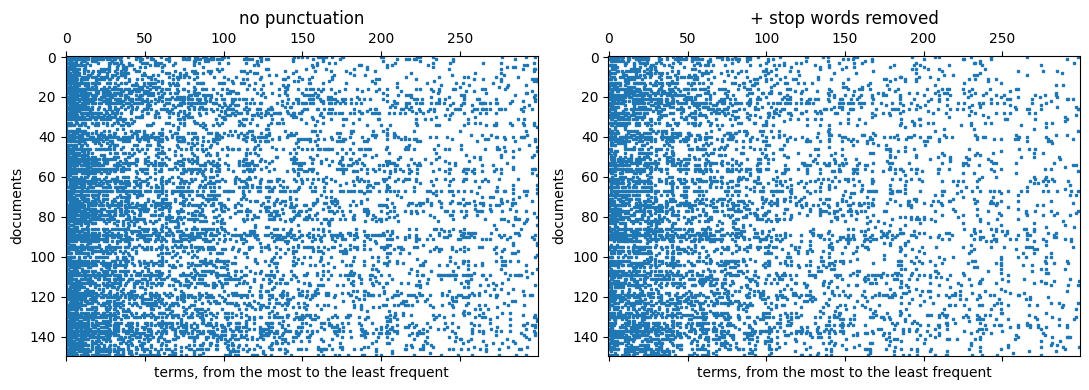

In [6]:
fig, ax = plt.subplots(ncols=2, figsize=(11, 4))

for a, name in zip(ax, ["no punctuation", "+ stop words removed"]):
    X, df, terms = matrices[name]
    columns = np.argsort(-df)[:300]
    a.spy(X[:150][:, columns], markersize=1.5, aspect="auto")
    a.set_title(name)
    a.set_xlabel("terms, from the most to the least frequent")
    a.set_ylabel("documents")

plt.tight_layout()
plt.show()

On the left, the first columns are the most frequent terms, and they are very full: `and` occurs in 95% of the documents, `in` in 85%, `a` in 83%. After removing the stop words (right), the first columns are less full: the most frequent term now occurs in 70% of the documents. The rest of the matrix is as empty as before.

### Generic and specific terms

Once the stop words are gone, which are the terms that occur in most documents?

In [7]:
X, df, terms = matrices["+ stop words removed"]
common = np.argsort(-df)[:10]

pd.DataFrame({"term": terms[common], "documents": df[common], "share of documents": df[common] / X.shape[0]}
             ).style.format({"share of documents": "{:.1%}"}).hide(axis="index")

term,documents,share of documents
minute,6938,69.7%
add,6912,69.5%
salt,5392,54.2%
heat,5163,51.9%
serve,5044,50.7%
stir,4711,47.3%
cook,4639,46.6%
pepper,4236,42.6%
oil,4149,41.7%
onion,4071,40.9%


They are not stop words, but they are not very informative either: in a collection of recipes, `add`, `minute` or `salt` tell us that a text is a recipe, not *which* recipe it is. At the other extreme there are the terms that occur in one document only. A useful feature has to be in between: shared by enough documents to relate them, and rare enough to distinguish them.

### What is merged, and what is lost

The normalization steps work by declaring that some different tokens are "the same" (or that some tokens do not matter). This is what makes the vocabulary smaller, but it is also what makes us lose information. Let's see some examples.

**Case.** Without lowercasing, the verbs that start a sentence in the instructions are a different feature from the same verbs in the middle of a sentence.

In [8]:
from collections import Counter, defaultdict

surface_forms = Counter(t.text for d in docs for t in d)

pd.DataFrame({"occurrences": {w: surface_forms[w] for w in ["add", "Add", "heat", "Heat", "with", "With"]}})

,occurrences
add,6091
Add,10830
heat,8330
Heat,2401
with,18244
With,1202


The gain is evident, but the price is that we cannot distinguish words that differ only by case. Two sentences that we made up as an example:

In [9]:
normalizer = TextNormalizer()

for text in ["Polish the silver.", "Fry the Polish sausage."]:
    print(f"{text:26}", normalizer(nlp(text)))

Polish the silver.         ['polish', 'the', 'silver']
Fry the Polish sausage.    ['fry', 'the', 'polish', 'sausage']


**Lemmatization.** A single lemma collects all the forms of a word. These are some of the lemmas of our corpus, with their most frequent forms:

In [10]:
forms = defaultdict(Counter)
for d in docs:
    for t in d:
        forms[t.lemma_.lower()][t.text.lower()] += 1

show({lemma: dict(forms[lemma].most_common(6)) for lemma in ["add", "cook", "stir", "be"]}, width=80)

{'add': {'add': 16936, 'adding': 484, 'added': 154, 'adds': 31},
 'cook': {'cook': 6929, 'cooked': 1400, 'cooking': 581, 'cooks': 83},
 'stir': {'stir': 6968, 'stirring': 2441, 'stirred': 12, 'stiring': 4},
 'be': {'is': 5733,
        'are': 3005,
        'be': 1931,
        "'s": 341,
        'been': 203,
        "'re": 126}}


But forms that carry different information can be merged as well: a *brown* sugar and a *browned* onion have become the same feature.

In [11]:
normalizer = TextNormalizer(lemmatize=True)

for text in ["Add the brown sugar.", "Add the browned onions."]:
    print(f"{text:26}", normalizer(nlp(text)))

Add the brown sugar.       ['add', 'the', 'brown', 'sugar']
Add the browned onions.    ['add', 'the', 'brown', 'onion']


**Stop words.** The list of stop words contains also the negations (`not`, `no`, `never`, `without`) and many prepositions and adverbs. Two sentences from our corpus:

In [12]:
normalizer = TextNormalizer(lemmatize=True, remove_stopwords=True)

for text in ["Drain but do not squeeze dry.", "Add pork and cook over high heat 5 minutes without stirring."]:
    show(text, width=80)
    show(normalizer(nlp(text)), width=80)
    print()

Drain but do not squeeze dry.
['drain', 'squeeze', 'dry']

Add pork and cook over high heat 5 minutes without stirring.
['add', 'pork', 'cook', 'high', 'heat', '5', 'minute', 'stir']



The instructions *not to squeeze* and *without stirring* have become *squeeze* and *stir*: the meaning is reversed. For a search on the ingredients this does not matter, while for tasks such as sentiment analysis, where `not good` is the opposite of `good`, removing the stop words can be a mistake.

### Trade-offs

There is no configuration that is right in general. Every choice moves us along three trade-offs:

- **Size of the vocabulary and expressiveness.** Normalizing produces smaller vocabularies, fewer distinct terms per document, and more overlap between related documents (`stirring` and `stir` become the same dimension). But every merge erases a distinction, and the distinctions that matter depend on the task.
- **Specific and generic features.** Terms that occur in a single document are too specific to relate documents, terms that occur everywhere are too generic to distinguish them. Normalization makes the features a little more general, and removing the stop words takes away the most extreme generic terms; but even after both steps half of the vocabulary occurs in a single document, and the most common terms are still in 70% of the documents.
- **Sparsity.** In every case the vectors are more than 99% zeros: a document uses a small part of the vocabulary. The density depends on how many features we merge and on how many very frequent features we keep.

## A search engine in the vector space

### Documents and queries are vectors

We now have a matrix in which every row is a document, expressed as a vector over the vocabulary. A **query** is nothing but a very short text: if we process it with the same normalization and we express it over the same vocabulary, it becomes a vector in the same space. Searching then means finding the documents that are **close** to the query.

We need two choices:

- a **weighting**: the number that we put in each cell, i.e. how much a term counts in a text. The most intuitive choice is the **raw frequency**: the number of times that the term occurs. This is what we have in the document-term matrix.
- a **proximity** between a query $q$ and a document $d$. We start from the simplest one, the dot product: the sum, over the terms, of the weight in the query multiplied by the weight in the document,

$$\text{score}(q, d) = \sum_t q_t \cdot d_t$$

For a query such as `chicken lemon`, in which each term occurs once, the score of a document is simply the number of times that `chicken` and `lemon` occur in it.

The class `SearchEngine` in [nlp/search.py](nlp/search.py) implements this engine: it builds the document-term matrix, it turns a query into a vector by applying the same preprocessing, and it ranks the documents by their score. We build one engine for each one of the normalization configurations of the previous section.

In [13]:
from nlp.search import SearchEngine

engines = {}
for name, normalizer in configurations.items():
    engine = SearchEngine(preprocess=lambda text, n=normalizer: n(nlp(text)))
    engines[name] = engine.fit([normalizer(doc) for doc in docs])

engine = engines["+ stop words removed"]
print(f"Matrix of the documents: {engine.matrix.shape[0]} documents x {engine.matrix.shape[1]} terms")

Matrix of the documents: 9951 documents x 13662 terms


### Ranking with the raw frequency

Let's search for `chicken lemon`. For each result we show the score and the length of the document, in terms.

In [14]:
import html

def results(query, engine=engine, k=10):
    lengths = engine.lengths
    return pd.DataFrame([{"title": html.unescape(recipes[i]["title"]), "score": s, "terms": lengths[i]}
                         for i, s in engine.search(query, k=k)])

results("chicken lemon")

,title,score,terms
0,Honey-Lemon Glazed Sesame Chicken,25.0,307
1,Orange Chicken W/ Warm Honey & Potato Cabbage ...,23.0,342
2,Lemon Chicken,20.0,254
3,Moroccan Chicken With Apricot Couscous and Gre...,20.0,318
4,Citrus BBQ Chicken in Crock Pot,20.0,150
5,Trinidad Stewed Chicken,19.0,279
6,Lemony Moroccan Style Chicken Kebabs,19.0,256
7,Guava-Stuffed Chicken With Caramelized Mango,17.0,221
8,Pistachio-Crusted Moroccan Rack of Lamb With I...,17.0,363
9,Thai-Style Grilled Chicken W/ Spicy Sweet and ...,17.0,362


The results look reasonable at first sight, even if one of them (the ninth) is a rack of lamb. But look at the last column: how long are these documents? The median length of the documents of the collection is 75 terms.

In [15]:
print(f"Median length of the documents in the collection: {np.median(engine.lengths):.0f} terms")
print(f"Documents that contain at least one of the two terms: {(engine.scores('chicken lemon') > 0).sum()}")

Median length of the documents in the collection: 75 terms
Documents that contain at least one of the two terms: 2962


### Long documents win

With the raw frequency, a document that is longer has more chances to contain a term many times, and so it gets a higher score, whether or not it is *about* that term. Let's measure it on several queries: for each of them, we compare the length of the documents that match the query with the length of the ten best results.

In [16]:
queries = ["chicken lemon", "chocolate cake", "spicy beef stew", "garlic butter shrimp", "vegetable soup", "apple pie"]

rows = {}
for query in queries:
    scores = engine.scores(query)
    matching = scores > 0
    top = np.argsort(-scores, kind="stable")[:10]
    rows[query] = {
        "matching documents": matching.sum(),
        "median length of matching documents": np.median(engine.lengths[matching]),
        "median length of the top 10": np.median(engine.lengths[top]),
    }

pd.DataFrame(rows).T.style.format("{:.0f}")

,matching documents,median length of matching documents,median length of the top 10
chicken lemon,2962,84,293
chocolate cake,793,85,212
spicy beef stew,1389,85,148
garlic butter shrimp,5400,87,202
vegetable soup,1756,86,142
apple pie,622,79,130


In every query, the best results are between 1.6 and 3.5 times longer than the typical document that contains the same terms. We can see it in the geometry of the space. Let's take only the two dimensions of the query, `chicken` and `lemon`: every document is a point, whose coordinates are the number of occurrences of the two terms, and the colour tells its length. The query is the vector $(1, 1)$, and the dashed line joins the documents that have the same score as the tenth result: everything above and to the right of it is in the top 10.

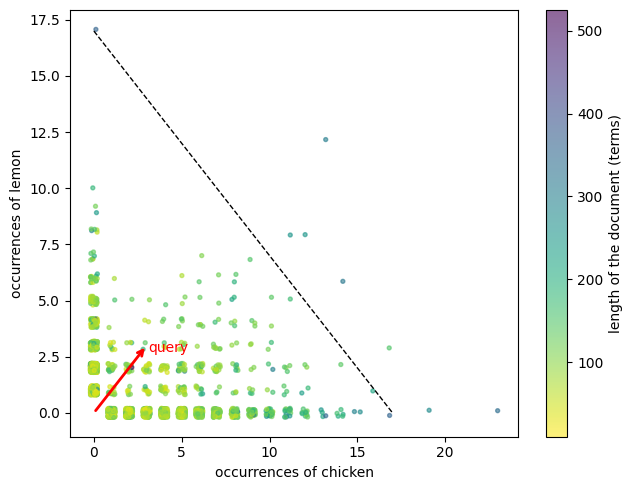

In [17]:
chicken = engine.matrix[:, engine.vocabulary["chicken"]].toarray().ravel()
lemon = engine.matrix[:, engine.vocabulary["lemon"]].toarray().ravel()
scores = engine.scores("chicken lemon")
threshold = np.sort(scores)[-10]

rng = np.random.default_rng(0)
shown = (chicken > 0) | (lemon > 0)

fig, ax = plt.subplots(figsize=(6.5, 5))
points = ax.scatter(chicken[shown] + rng.uniform(-0.2, 0.2, shown.sum()),
                    lemon[shown] + rng.uniform(-0.2, 0.2, shown.sum()),
                    c=engine.lengths[shown], s=8, alpha=0.6, cmap="viridis_r")
ax.plot([0, threshold], [threshold, 0], color="black", linestyle="--", linewidth=1)
ax.annotate("", xy=(3, 3), xytext=(0, 0), arrowprops=dict(arrowstyle="->", color="red", linewidth=2))
ax.text(3.1, 2.7, "query", color="red")
ax.set_xlabel("occurrences of chicken")
ax.set_ylabel("occurrences of lemon")
fig.colorbar(points, label="length of the document (terms)")
plt.tight_layout()
plt.show()

The points that are far from the origin are the long documents. The score of a document is a measure of how far it is along the direction of the query, and so it grows with the length of the text.

The opposite happens to the short documents that are entirely about the query. Take the recipes that have both `lemon` and `chicken` in the title, and look at their position in the ranking.

In [18]:
import re

lengths = engine.lengths
ranking = np.argsort(-engine.scores("chicken lemon"), kind="stable")
position = {doc: rank + 1 for rank, doc in enumerate(ranking)}

both = [i for i, r in enumerate(recipes) if {"lemon", "chicken"} <= set(re.findall(r"\w+", r["title"].lower()))]
table = pd.DataFrame([{"title": html.unescape(recipes[i]["title"]), "terms": lengths[i],
                       "score": engine.scores("chicken lemon")[i], "rank": position[i]} for i in both])
table.sort_values("rank").reset_index(drop=True)

,title,terms,score,rank
0,Honey-Lemon Glazed Sesame Chicken,307,25,1
1,Lemon Chicken,254,20,3
2,Chicken Tagine With Olives and Lemon,145,14,23
3,Lemon Chicken,119,13,29
4,Lemon Stuffed Chicken Thighs With Chermoula,108,13,37
5,Easy Chicken Tagine/Tajine With Olives and Lemon,106,13,38
6,"Lemon, Chicken & Green Olive Tagine",122,12,56
7,Hot and Sour Soup With Chicken and Lemon Grass,160,12,64
8,Chicken With Lemon-Egg Sauce,93,11,69
9,Chicken Tajine With Preserved Lemon and Olives,173,11,74


All these recipes have both words in the title, so all of them are clearly relevant, but their positions are very different. The best ones are the longest (307 and 254 terms at ranks 1 and 3), while the short ones are buried: `Moroccan Lemon Chicken` (59 terms) is at rank 113, a `Lemon Chicken` with 61 terms at rank 384, and `Lemon Chicken Salad` (40 terms) at rank 1,117, among the 2,962 documents that match the query.

With the raw frequency, the score measures how much text says `chicken` and `lemon`, not how much of the text is about them. A weighting that ignores the length of the documents is not a good measure of relevance.

### Normalization choices and search results

The engines that we built follow the five configurations of the first part of the notebook. The choices that we make in the normalization decide what is a match between a query and a document. Let's compare the number of documents that match the query and the best results, for four queries and for the normalization configurations (the first one, `raw tokens`, is omitted because it is equal to `no punctuation` on these queries).

In [19]:
def compare(query, k=3):
    rows = {}
    for name, e in engines.items():
        if name == "raw tokens":
            continue
        rows[name] = {
            "matching documents": int((e.scores(query) > 0).sum()),
            "best results": " | ".join(html.unescape(recipes[i]["title"]) for i, _ in e.search(query, k=k)),
        }
    return pd.DataFrame(rows).T

pd.set_option("display.max_colwidth", None)

for query in ["Lemon chicken", "lemon chicken", "stirring onions", "roasted vegetables"]:
    print(query)
    display(compare(query))

Lemon chicken


,matching documents,best results
no punctuation,1955,Orange Chicken W/ Warm Honey & Potato Cabbage Salad | Trinidad Stewed Chicken | Citrus BBQ Chicken in Crock Pot
+ lowercase,2947,Honey-Lemon Glazed Sesame Chicken | Orange Chicken W/ Warm Honey & Potato Cabbage Salad | Trinidad Stewed Chicken
+ lemmatization,2962,Honey-Lemon Glazed Sesame Chicken | Orange Chicken W/ Warm Honey & Potato Cabbage Salad | Lemon Chicken
+ stop words removed,2962,Honey-Lemon Glazed Sesame Chicken | Orange Chicken W/ Warm Honey & Potato Cabbage Salad | Lemon Chicken


lemon chicken


,matching documents,best results
no punctuation,2920,Orange Chicken W/ Warm Honey & Potato Cabbage Salad | Trinidad Stewed Chicken | Honey-Lemon Glazed Sesame Chicken
+ lowercase,2947,Honey-Lemon Glazed Sesame Chicken | Orange Chicken W/ Warm Honey & Potato Cabbage Salad | Trinidad Stewed Chicken
+ lemmatization,2962,Honey-Lemon Glazed Sesame Chicken | Orange Chicken W/ Warm Honey & Potato Cabbage Salad | Lemon Chicken
+ stop words removed,2962,Honey-Lemon Glazed Sesame Chicken | Orange Chicken W/ Warm Honey & Potato Cabbage Salad | Lemon Chicken


stirring onions


,matching documents,best results
no punctuation,3224,Spaghetti & Meatballs | Caribbean Beef Barley Soup With Vegetables | Marsala Chicken Stew
+ lowercase,3241,Spaghetti & Meatballs | Caribbean Beef Barley Soup With Vegetables | Marsala Chicken Stew
+ lemmatization,6526,"Stir-Fried Chicken, Black Mushrooms, Bamboo Shoots and Spinach | Aloo Keema | Chicken in a Fried Onion Sauce"
+ stop words removed,6526,"Stir-Fried Chicken, Black Mushrooms, Bamboo Shoots and Spinach | Aloo Keema | Chicken in a Fried Onion Sauce"


roasted vegetables


,matching documents,best results
no punctuation,850,Baked Squash Sticks | Baked Vegetable Sticks | Indiana Garden Stir-Fry
+ lowercase,940,"Asian Stir Fry Noodles, Vegetables and Shrimp - Low Fat | Baked Squash Sticks | Baked Vegetable Sticks"
+ lemmatization,1456,Fall-Off-The-Bone Beef Roast | Pot Roast | Boliche Relleno (Stuffed Boliche) - Eye of the Round Roast
+ stop words removed,1456,Fall-Off-The-Bone Beef Roast | Pot Roast | Boliche Relleno (Stuffed Boliche) - Eye of the Round Roast


The normalization decides what counts as a match:

- **Case.** If terms are case-sensitive, `Lemon chicken` and `lemon chicken` are different queries: they match 1,955 and 2,920 documents, because `Lemon` with the capital letter matches only the documents in which the word is capitalized (mostly the titles). With lowercasing they become the same query (2,947 matching documents).
- **Lemmatization** makes the query match more documents. `stirring onions` matches 6,526 documents instead of 3,241, because now `stir`, `stirred`, `onion` and `onions` are the same as the words of the query. But some of the new matches are not what we meant: the first result is a stir-fried dish, matched by the `stir` of `Stir-Fried`.
- **Merging two meanings.** With lemmatization `roasted` and `roast` are the same term, and the best results for `roasted vegetables` become a `Beef Roast` and a `Pot Roast`.

Each choice changes both *how many* documents are found and *which ones* are at the top: the normalization is part of the definition of proximity between a query and a document.

## Term frequency

The weight that we have used so far, the number of times that a term occurs in a document, is called **term frequency** (TF). We have seen that, as it is, it depends on the length of the document: a long text has more chances to repeat a term. To remove this dependence we can *normalize* the frequency in at least two ways:

- **by the length** of the document: the share of the terms of the document that are $t$,

$$\text{tf}(t, d) = \frac{\text{count}(t, d)}{\sum_{t'} \text{count}(t', d)}$$

- **by the maximum frequency**: the count of $t$ relative to the count of the most frequent term of the document, so that the weight is between 0 and 1, and it is 1 for the most frequent term,

$$\text{tf}(t, d) = \frac{\text{count}(t, d)}{\max_{t'} \text{count}(t', d)}$$

The class `SearchEngine` accepts these weightings (`tf_length` and `tf_max`, besides the default `count`). Let's build the three engines, on the same terms, and let's compare them on the query that we used before.

In [20]:
term_lists = [configurations["+ stop words removed"](doc) for doc in docs]

tf_engines = {
    "raw frequency": engine,
    "frequency / length": SearchEngine(engine.preprocess, weighting="tf_length").fit(term_lists),
    "frequency / maximum": SearchEngine(engine.preprocess, weighting="tf_max").fit(term_lists),
}

for name, e in tf_engines.items():
    print(name)
    display(results("chicken lemon", engine=e))

raw frequency


,title,score,terms
0,Honey-Lemon Glazed Sesame Chicken,25.0,307
1,Orange Chicken W/ Warm Honey & Potato Cabbage Salad,23.0,342
2,Lemon Chicken,20.0,254
3,Moroccan Chicken With Apricot Couscous and Green Olive Sauce,20.0,318
4,Citrus BBQ Chicken in Crock Pot,20.0,150
5,Trinidad Stewed Chicken,19.0,279
6,Lemony Moroccan Style Chicken Kebabs,19.0,256
7,Guava-Stuffed Chicken With Caramelized Mango,17.0,221
8,Pistachio-Crusted Moroccan Rack of Lamb With Israeli Couscous,17.0,363
9,Thai-Style Grilled Chicken W/ Spicy Sweet and Sour Dipping Sauce,17.0,362


frequency / length


,title,score,terms
0,Yummy and Quick Chicken,0.250000,20
1,Lemon Creme,0.176471,17
2,Moroccan Lemon Chicken,0.169492,59
3,Sherbert Lemonade,0.166667,12
4,Star Drink,0.166667,12
5,Salsa Chicken,0.166667,48
6,Chicken Broccoli Casserole,0.162162,37
7,Glazed Balsamic Chicken,0.161290,62
8,Pickled Lemon Slices,0.156250,32
9,Green Salsa Chicken,0.155172,58


frequency / maximum


,title,score,terms
0,Greek Lemon Chicken & Vegetables,2.000000,88
1,Honey-Lemon Glazed Sesame Chicken,1.923077,307
2,Lemon Chicken,1.857143,119
3,Lemon Stuffed Chicken Thighs With Chermoula,1.857143,108
4,"Chicken Tagine with Figs, Olives, and Pistachios",1.833333,132
5,Lemon Garlic Chicken,1.833333,74
6,Moroccan Chicken and Date Tagine,1.800000,113
7,Chicken Tagine With Green Olives & Preserved Lemon,1.800000,114
8,Healthy Thai Chicken-Coconut Soup,1.800000,148
9,Chicken Tagine for 2,1.777778,149


With the raw frequency (first table) the best results are long documents (150 to 363 terms). Divided by the length (second table) the best results are very short, from 12 to 62 terms, and some of them are not even about chicken (`Sherbert Lemonade`, `Star Drink`, `Lemon Creme`, `Pickled Lemon Slices`): a single mention of a term takes a big share of a document of a few terms. Divided by the maximum (third table) the lengths are back to a normal range (74 to 307 terms), and the results are chicken recipes in which both terms are among the most frequent ones (a score of 2 means that both `chicken` and `lemon` are the most frequent terms of the document).

Let's see if this is a general behavior. For each query, we compare the median length of the documents that match the query with the median length of the ten best results.

In [21]:
rows = {}
for query in queries:
    row = {"matching documents": np.median(engine.lengths[engine.scores(query) > 0])}
    for name, e in tf_engines.items():
        top = [i for i, _ in e.search(query, k=10)]
        row[f"top 10, {name}"] = np.median(engine.lengths[top])
    rows[query] = row

pd.DataFrame(rows).T.style.format("{:.0f}")

,matching documents,"top 10, raw frequency","top 10, frequency / length","top 10, frequency / maximum"
chicken lemon,84,293,34,116
chocolate cake,85,212,32,118
spicy beef stew,85,148,30,60
garlic butter shrimp,87,202,42,66
vegetable soup,86,142,52,52
apple pie,79,130,28,68


With the raw frequency the best results are 1.6 to 3.5 times longer than the typical matching document. Dividing by the length pushes them *below* the typical length (28 to 52 terms, against 79 to 87): the bias in favor of long documents has become a bias in favor of short ones. Dividing by the maximum gives lengths (52 to 118 terms) that are much closer to the typical ones.

We can check the effect on the recipes that we know to be relevant: the ones that have both `lemon` and `chicken` in the title. The first table shows the rank of the shortest ones (fewer than 100 terms) and of the longest ones (250 terms or more) with the three weightings; the second one summarizes the rank of all the 23 recipes.

In [22]:
def positions(e, query):
    order = np.argsort(-e.scores(query), kind="stable")
    rank = np.empty(len(order), dtype=int)
    rank[order] = np.arange(1, len(order) + 1)
    return rank

ranks = {name: positions(e, "chicken lemon") for name, e in tf_engines.items()}

extreme = [i for i in both if engine.lengths[i] < 100 or engine.lengths[i] >= 250]
display(pd.DataFrame({"terms": engine.lengths[extreme], **{name: r[extreme] for name, r in ranks.items()}},
                     index=[html.unescape(recipes[i]["title"]) for i in extreme]).sort_values("terms"))

pd.DataFrame({name: {"mean rank": r[both].mean(), "in the top 10": int((r[both] <= 10).sum()),
                     "in the top 30": int((r[both] <= 30).sum())} for name, r in ranks.items()}
             ).style.format("{:.1f}", subset=pd.IndexSlice["mean rank", :])

,terms,raw frequency,frequency / length,frequency / maximum
Lemon Chicken Salad,40,1117,160,107
Moroccan Lemon Chicken,59,113,3,24
Lemon Chicken,61,384,84,14
Light Lemon Chicken,65,326,120,11
Lemon Chicken (Chinese Style),66,222,61,85
Lemon Garlic Chicken,74,86,15,6
Lemon Chicken and Spring Veg Noodles,82,101,59,61
Greek Lemon Chicken & Vegetables,88,105,87,1
"Grilled Chicken Marinated in Cumin, Lemon and Garlic",89,267,245,34
Chicken With Lemon-Egg Sauce,93,69,70,81


,raw frequency,frequency / length,frequency / maximum
mean rank,196.3,277.4,137.5
in the top 10,2.000000,1.000000,6.000000
in the top 30,4.000000,2.000000,11.000000


With the raw frequency the short recipes are buried (`Lemon Chicken Salad` is 1,117th, a `Lemon Chicken` of 61 terms is 384th). Dividing by the length lifts them (`Moroccan Lemon Chicken` goes from 113th to 3rd) but it pushes down the long ones that were correctly at the top (the `Lemon Chicken` of 254 terms goes from 3rd to 369th). Dividing by the maximum lifts the short recipes (`Greek Lemon Chicken & Vegetables` from 105th to 1st, `Light Lemon Chicken` from 326th to 11th) and it keeps the long ones near the top (`Honey-Lemon Glazed Sesame Chicken` is 2nd, the `Lemon Chicken` of 254 terms is 19th).

Over all the 23 recipes, the mean rank goes from 196 (raw frequency) to 277 (length) to 137 (maximum), and the recipes in the top 10 from 2 to 1 to 6. The title is only a proxy of relevance, but the comparison is clear.

The normalization by the maximum has a weak point, though: the weight of a term depends on the count of *another* term, the most frequent one. Take two recipes in which `chicken` occurs exactly four times.

In [23]:
counts_chicken = engine.matrix[:, engine.vocabulary["chicken"]].toarray().ravel()
maximum = engine.matrix.max(axis=1).toarray().ravel()
terms = engine.vectorizer.get_feature_names_out()

candidates = np.where(counts_chicken == 4)[0]
picked = [candidates[np.argmin(maximum[candidates])], candidates[np.argmax(maximum[candidates])]]

pd.DataFrame([{
    "title": html.unescape(recipes[i]["title"]),
    "terms": engine.lengths[i],
    "chicken": counts_chicken[i],
    "most frequent term": f"{terms[engine.matrix[i].toarray().argmax()]} ({maximum[i]:.0f})",
    "tf / length": counts_chicken[i] / engine.lengths[i],
    "tf / maximum": counts_chicken[i] / maximum[i],
} for i in picked]).style.format({"tf / length": "{:.3f}", "tf / maximum": "{:.2f}"}).hide(axis="index")

title,terms,chicken,most frequent term,tf / length,tf / maximum
Bahama-Mama Pork Chops or Chicken,53,4,chicken (4),0.075,1.00
Southwestern Chicken-Corn Cakes,141,4,corn (10),0.028,0.40


In the first recipe `chicken` is the most frequent term and its weight is 1. In the second one `corn` occurs ten times, so `chicken` is worth only 0.4, even if it is the same count. The normalization by the length has the same kind of problem in a different form: the weight of a term depends on how many other terms are in the document (0.075 against 0.028).

There is no perfect normalization. In the rest of the notebook we use the **normalization by the maximum frequency**, because with the dot product as a proximity it is the one that removes the advantage of the long documents without replacing it with an advantage for the short ones. The comparison holds for this proximity and for these queries: with a different way of measuring the proximity between two vectors the conclusion could be different.

### TF in a recipe

Let's see what the term frequency says about a single recipe.

In [24]:
crumble = next(i for i, r in enumerate(recipes) if r["title"].startswith("Barefoot Contessa's Plum Raspberry"))
show(documents[crumble], width=90)

Barefoot Contessa's Plum Raspberry Crumble. red plums, granulated sugar, all-purpose
flour, fresh raspberry, light brown sugar, kosher salt, unsalted butter, quick-cooking
oats. Preheat the oven to 350 degrees. In a large bowl, combine the sliced plums, 1/3 cup
of the granulated sugar, 1/4 cup of the flour, and the orange juice and toss well. Add the
raspberries and toss lightly. Pour into a 9 by 12 by 2-inch baking dish. For the topping,
place the remaining 1 cup of flour, the remaining 1/3 cup of granulated sugar, the brown
sugar, and the salt in the bowl of a food processor fitted with a steel blade and pulse a
few times to combine. Add the butter and pulse until the butter is the size of peas. Pour
the mixture into a bowl, add the oats, and work it with your hands until it's in large
crumbles. Add 1/2 cup of the almonds and mix well. Spread the topping evenly over the
plums, making sure the fruit is covered. Sprinkle with some extra almonds. Bake for 40
minutes, or until the fruit 

These are the terms with the highest TF in this recipe. Within a document the normalization does not change the *order* of the terms, because we divide all the counts by the same number: it changes only the scale, and it makes the weights of different documents comparable.

In [25]:
row = engine.matrix[crumble].toarray().ravel()
tf = row / row.max()
top = np.argsort(-tf, kind="stable")[:12]

pd.DataFrame({"term": terms[top], "count": row[top].astype(int), "tf": tf[top]}
             ).style.format({"tf": "{:.2f}"}).hide(axis="index")

term,count,tf
cup,5,1.00
sugar,5,1.00
add,4,0.80
plum,4,0.80
bowl,3,0.60
brown,3,0.60
butter,3,0.60
flour,3,0.60
granulated,3,0.60
raspberry,3,0.60


The terms with the highest TF are `cup` and `sugar` (1.0), then `add` and `plum` (0.8), then `bowl`, `brown`, `butter`, `flour`, `granulated` and `raspberry` (0.6). Some of them describe the dish (`plum`, `raspberry`), but the two most frequent ones are `cup` and `sugar`, and `add` and `bowl` are in the list. They are the words that any recipe needs, not the ones that make this recipe a plum and raspberry crumble.

### From frequent to significant

A term is a good feature of a document if it says something about *that* document, that is, if it distinguishes it from the others. The terms above are frequent in this recipe, but are they specific to it? Let's count how many documents of the collection contain each of them.

In [26]:
n_docs = engine.matrix.shape[0]
doc_freq = np.asarray((engine.matrix > 0).sum(axis=0)).ravel()

pd.DataFrame({"term": terms[top], "tf": tf[top], "documents containing the term": doc_freq[top],
              "share of the collection": doc_freq[top] / n_docs}
             ).style.format({"tf": "{:.2f}", "share of the collection": "{:.1%}"}).hide(axis="index")

term,tf,documents containing the term,share of the collection
cup,1.00,2002,20.1%
sugar,1.00,3413,34.3%
add,0.80,6912,69.5%
plum,0.80,139,1.4%
bowl,0.60,3931,39.5%
brown,0.60,3397,34.1%
butter,0.60,2460,24.7%
flour,0.60,2323,23.3%
granulated,0.60,222,2.2%
raspberry,0.60,78,0.8%


The most frequent terms of the recipe are also very frequent in the collection: `add` is in 69.5% of the recipes, `bowl` in 39.5%, `sugar` in 34.3%. The terms that characterize the recipe are rare: `plum` is in 1.4% of the recipes and `raspberry` in 0.8%. Being frequent in a document is not enough to be significant: what matters is being frequent in the document *and* rare in the collection.

### Inverse document frequency

We need a weight that decreases with the number of documents in which a term occurs: the more documents contain the term, the less it says about each one of them. If $N$ is the number of documents in the collection and $\text{df}(t)$ is the number of documents that contain $t$, the **inverse document frequency** is

$$\text{idf}(t) = \log \frac{N}{\text{df}(t)}$$

It is 0 for a term that occurs in every document, and it grows for the rarer terms. The logarithm makes the weight decrease smoothly: a term that occurs in 10 documents is not a thousand times more informative than one that occurs in 10,000.

If we multiply the two weights, we obtain the **TF-IDF** of a term in a document, which is high when the term is frequent in the document and rare in the collection:

$$\text{tf-idf}(t, d) = \text{tf}(t, d) \times \text{idf}(t)$$

Let's compare, for the same recipe, the terms with the highest TF and the ones with the highest TF-IDF.

In [27]:
idf = np.log(n_docs / doc_freq)
tfidf = tf * idf

def top_terms(weights, n=10):
    order = np.argsort(-weights, kind="stable")[:n]
    return pd.DataFrame({"term": terms[order], "weight": weights[order]})

pd.concat({"TF": top_terms(tf), "TF-IDF": top_terms(tfidf)}, axis=1).style.format(precision=2)

With TF-IDF the ranking changes: `plum` and `raspberry` are the first two terms, followed by `granulated`, `oats` and `pulse`, which are a much better description of the recipe. `add` and `bowl` are gone from the top 10. `cup` is still there: it is very frequent in the recipe (TF of 1) and its IDF (1.60) does not cancel it completely.

Notice also `barefoot` and `contessa`: they come from the title (*Barefoot Contessa's ...*), they are rare in the collection, and so they get a high weight even if they say nothing about the dish. The IDF rewards rarity, and rarity is not always a sign of significance.

We now have the two components of the TF-IDF weighting. Let's see what they do to the search.

## TF-IDF in the search engine

### Adding the IDF

The class `SearchEngine` also accepts `weighting="tfidf"`: the weight of a term in a document is its TF normalized by the maximum, multiplied by its IDF.

To see the effect, we need queries like the ones that we write in practice, in which generic and specific terms are mixed. Take `add cook saffron`. In this collection `add` and `cook` are in thousands of recipes, `saffron` in a hundred. The recipes that we are looking for are the ones about saffron.

In [28]:
tfidf_engine = SearchEngine(engine.preprocess, weighting="tfidf").fit(term_lists)

weightings = {
    "raw frequency": engine,
    "TF (maximum)": tf_engines["frequency / maximum"],
    "TF-IDF": tfidf_engine,
}

query_terms = ["add", "cook", "saffron"]
print(pd.DataFrame({"documents containing the term": [tfidf_engine.doc_freq[tfidf_engine.vocabulary[t]] for t in query_terms],
                    "idf": [tfidf_engine.idf[tfidf_engine.vocabulary[t]] for t in query_terms]}, index=query_terms).round(2))

         documents containing the term   idf
add                               6912  0.36
cook                              4639  0.76
saffron                            108  4.52


For each weighting, these are the five best results for the query. The last column counts the occurrences of `saffron` in the recipe.

In [29]:
def with_term(query, term, e, k=5):
    j = engine.vocabulary[term]
    return pd.DataFrame([{"title": html.unescape(recipes[i]["title"]), "score": s, "terms": engine.lengths[i],
                          term: int(engine.counts[i, j])} for i, s in e.search(query, k=k)])

for name, e in weightings.items():
    print(name)
    display(with_term("add cook saffron", "saffron", e))

raw frequency


,title,score,terms,saffron
0,"Asian Stir Fry Noodles, Vegetables and Shrimp - Low Fat",24.0,313,0
1,Indian Butter Chicken,22.0,222,0
2,Honey Lime Chipotle Chicken Fajita Bowls W/Chipotle Lime Crema,21.0,295,0
3,Huang He Fried Rice,20.0,238,0
4,Aloo Keema,20.0,222,0


TF (maximum)


,title,score,terms,saffron
0,Persian Lamb or Beef Pumpkin Stew,2.2,99,2
1,Cuban Style Picadillo,2.0,99,0
2,Island Rice With Cumin and Coconut,2.0,61,0
3,German Potatoes,2.0,38,0
4,Braised Sauerkraut - Pressure Cooker,2.0,76,0


TF-IDF


,title,score,terms,saffron
0,Saffron Almond Rice,4.644768,50,3
1,Saffron Orangeade,4.614401,37,4
2,Mango Lassi,4.523297,13,1
3,Qahwa (Kashmiri Tea),4.523297,25,2
4,Milk With Saffron,4.523297,32,3


With the raw frequency none of the five best results contains `saffron`: the score is made by `add` and `cook`, that recur many times in long recipes (222 to 313 terms), and the only specific term of the query has no influence. With the TF normalized by the maximum, the first result contains `saffron`, and the other four do not. With TF-IDF, all the five results are about saffron (`Saffron Almond Rice`, `Saffron Orangeade`, `Milk With Saffron`): the IDF of `add` is 0.36 and the one of `cook` is 0.76, against 4.52 of `saffron`, so the specific term weighs more than ten times the generic one.

The recipes at the top are short ones (13 to 50 terms). In them `saffron` is one of the most frequent terms, so its TF is high: this is the weak point of the normalization by the maximum that we have seen before. Let's check on other queries how many of the ten best results contain the specific term.

In [30]:
specific = [("add cook saffron", "saffron"), ("minute heat salt tahini", "tahini"), ("add sugar plum", "plum")]

pd.DataFrame({
    f"{query} ({term})": {name: np.mean([engine.counts[i, engine.vocabulary[term]] > 0 for i, _ in e.search(query, k=10)])
                          for name, e in weightings.items()}
    for query, term in specific
}).T.style.format("{:.0%}")

,raw frequency,TF (maximum),TF-IDF
add cook saffron (saffron),0%,10%,100%
minute heat salt tahini (tahini),0%,10%,100%
add sugar plum (plum),20%,40%,100%


In the three queries, the specific term is in none or in very few of the best results with the raw frequency and with the TF alone (0% to 40%), and in all of them with TF-IDF. The generic terms (`add`, `cook`, `minute`, `heat`, `salt`) are in most of the documents and, without the IDF, they decide the ranking.

What happens if the terms of the query have similar IDF? Let's go back to `chicken lemon`, and to the 23 recipes with both words in the title.

In [31]:
idf_of = {t: tfidf_engine.idf[tfidf_engine.vocabulary[t]] for t in ["chicken", "lemon"]}
print({t: round(v, 2) for t, v in idf_of.items()})

pd.DataFrame({name: {"mean rank": positions(e, "chicken lemon")[both].mean(),
                     "in the top 10": int((positions(e, "chicken lemon")[both] <= 10).sum())}
              for name, e in weightings.items()}).style.format("{:.1f}", subset=pd.IndexSlice["mean rank", :])

{'chicken': 1.68, 'lemon': 1.96}


,raw frequency,TF (maximum),TF-IDF
mean rank,196.3,137.5,134.6
in the top 10,2.000000,6.000000,7.000000


For `chicken lemon` the IDF changes little (the mean rank goes from 137.5 to 134.6, and the recipes in the top 10 from 6 to 7). The two terms have a similar IDF (1.68 and 1.96) and there is no generic term to discount. The IDF makes the difference when a query mixes terms that occur in many documents with terms that occur in few, that is when the query has a specific part and a generic part.

### Other ways to measure the proximity

So far we have ranked the documents by their dot product with the query. There are alternatives, that use the geometry of the space in a different way:

- the **euclidean distance** is the length of the segment that joins the two vectors,

$$d(q, d) = \sqrt{\sum_t (q_t - d_t)^2}$$

the closer the vectors, the smaller the distance; to rank the documents we take the smallest ones first;

- the **cosine similarity** is the cosine of the angle between the two vectors,

$$\cos(q, d) = \frac{\sum_t q_t \, d_t}{\sqrt{\sum_t q_t^2} \; \sqrt{\sum_t d_t^2}}$$

it is the dot product divided by the norms of the vectors, so it depends only on the *direction* of the vectors, and not on their length.

The class accepts `similarity="cosine"` and `similarity="euclidean"`. Let's compare them on `chicken lemon`, with the TF-IDF weights.

In [32]:
similarity_engines = {
    "dot product": tfidf_engine,
    "cosine": SearchEngine(engine.preprocess, weighting="tfidf", similarity="cosine").fit(term_lists),
    "euclidean distance": SearchEngine(engine.preprocess, weighting="tfidf", similarity="euclidean").fit(term_lists),
}

query = "chicken lemon"
query_columns = [engine.vocabulary[t] for t in ["chicken", "lemon"]]

rows = {}
for name, e in similarity_engines.items():
    top = [i for i, _ in e.search(query, k=10)]
    present = np.array([[engine.counts[i, j] > 0 for j in query_columns] for i in top])
    rows[name] = {
        "median length of the top 10": np.median(engine.lengths[top]),
        "with both terms": present.all(axis=1).mean(),
        "with no query term": (~present.any(axis=1)).mean(),
        "mean rank of the 23 recipes": positions(e, query)[both].mean(),
    }

pd.DataFrame(rows).T.style.format({"median length of the top 10": "{:.0f}", "with both terms": "{:.0%}",
                                   "with no query term": "{:.0%}", "mean rank of the 23 recipes": "{:.0f}"})

,median length of the top 10,with both terms,with no query term,mean rank of the 23 recipes
dot product,114,100%,0%,135
cosine,84,90%,0%,187
euclidean distance,58,30%,10%,1869


In [33]:
results("chicken lemon", engine=similarity_engines["euclidean distance"], k=8)

,title,score,terms
0,Glazed Balsamic Chicken,-2.232674,62
1,Green Salsa Chicken,-2.498145,58
2,Yummy and Quick Chicken,-2.551448,20
3,Salsa Chicken,-2.703217,48
4,Chicken & Dumplings,-2.796481,55
5,Onion Soup,-2.803851,26
6,Grenadian Style Baked Chicken,-2.808560,78
7,Chicken Soup,-2.832800,58


With the dot product all the ten best results contain both terms, but they are somewhat longer than the typical matching document (median of 114 terms, against 84): the dot product still grows with the length of the vectors. The cosine similarity removes this effect, and the median length of the results is the typical one (84).

The euclidean distance is the least suited to this task: only 3 results out of 10 contain both terms, one of them (`Onion Soup`) contains neither, and the mean rank of our 23 recipes falls to 1,869. A short document is a vector close to the origin, and so it is close to any short query, whether or not it contains its terms: the euclidean distance measures the difference between the lengths of two vectors as much as the difference between their directions.

The cosine similarity is the most used measure with TF-IDF, because it does not depend on the length of the vectors. On our proxy of relevance the dot product does slightly better (135 against 187), which shows that there is no measure that is better in general: the choice depends on the collection and on how much we want the length of the documents to matter.

## Okapi BM25

### The intuition

TF-IDF is a good starting point, but we have seen its limits. In particular:

- the weight of a term **grows linearly** with its frequency (or, with the normalization by the maximum, with its frequency relative to the most frequent term). Is a term that occurs ten times in a document really ten times more important than a term that occurs once? The first occurrence tells us that the document is *about* the term; the tenth adds very little.
- the normalization for the length of the document is **all or nothing**: we divide by the length, or by the maximum, and we have seen that this can overshoot, and favor the shortest documents, or depend on a single term.

**BM25** (*Best Match 25*) is a ranking function that was developed in the 1990s by Stephen Robertson and colleagues, in the Okapi information retrieval system, from a probabilistic model of relevance. It uses the same three ingredients as TF-IDF (the frequency of the term in the document, the rarity of the term in the collection, the length of the document), but it shapes them differently. For a query $q$ and a document $d$:

$$\text{BM25}(q, d) = \sum_{t \in q} \text{idf}(t) \cdot \frac{f(t, d) \, (k_1 + 1)}{f(t, d) + k_1 \left(1 - b + b \, \frac{|d|}{\text{avgdl}}\right)}$$

where $f(t, d)$ is the number of occurrences of $t$ in $d$, $|d|$ is the length of the document, $\text{avgdl}$ is the average length of the documents of the collection, and $k_1$ and $b$ are two parameters. Let's look at the three parts.

**1. The IDF.** It is the rarity of the term, as before. In BM25 it is usually written with a small smoothing that keeps it positive even for terms that are in more than half of the documents:

$$\text{idf}(t) = \ln \left( 1 + \frac{N - n_t + 0.5}{n_t + 0.5} \right)$$

with $N$ the number of documents and $n_t$ the number of documents that contain $t$.

**2. Saturation of the frequency.** If we ignore the length for a moment, the frequency part is

$$\frac{f \, (k_1 + 1)}{f + k_1}$$

It is 0 when the term is absent, it grows with $f$, but it is bounded by $k_1 + 1$: the first occurrences count a lot, the following ones less and less. The parameter $k_1$ decides how fast the curve saturates: with $k_1 = 0$ what matters is only whether the term is present or not; with a very large $k_1$ the weight is proportional to the raw frequency.

**3. Length normalization.** The length enters the denominator through the ratio $|d| / \text{avgdl}$: a document that is longer than average has a larger denominator, and so its frequencies are discounted; a shorter one is boosted. The parameter $b$, between 0 and 1, says how much: with $b = 0$ the length is ignored, with $b = 1$ the normalization is complete. The usual choice is $b = 0.75$. Note that the discount depends on *how much longer than average* the document is, and it acts *inside* the saturation: it cannot make a single mention weigh more than the bound $k_1 + 1$.

The score of a document is the sum of the contributions of the terms of the query: it is still a dot product between the query and a vector of weights of the document, and so BM25 is another weighting for the same vector space. The usual values of the parameters are $k_1$ between 1.2 and 2, and $b = 0.75$.

The two plots show the frequency part. On the left, the effect of $k_1$, against the raw frequency. On the right, the effect of the length, with $k_1 = 1.2$ and $b = 0.75$: for the same frequency, a long document is worth less than an average one, and a short one more.

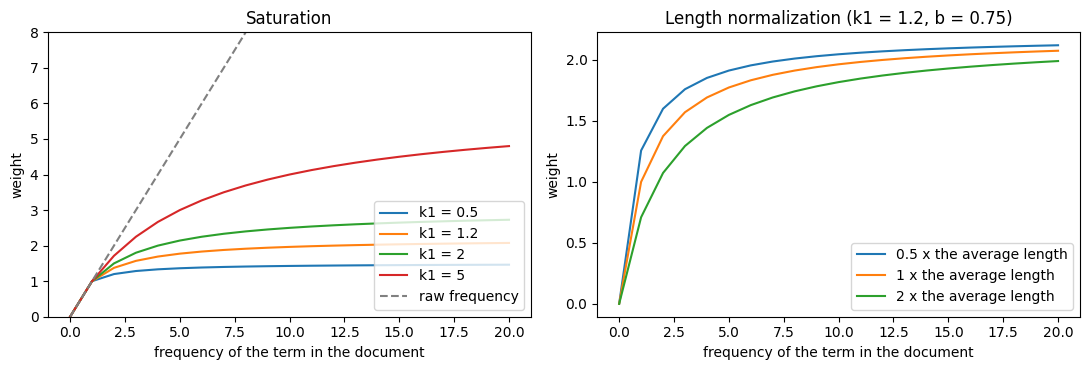

In [34]:
f = np.arange(0, 21)

fig, ax = plt.subplots(ncols=2, figsize=(11, 3.8))

for k1 in [0.5, 1.2, 2, 5]:
    ax[0].plot(f, f * (k1 + 1) / (f + k1), label=f"k1 = {k1}")
ax[0].plot(f, f, color="gray", linestyle="--", label="raw frequency")
ax[0].set_ylim(0, 8)
ax[0].set_xlabel("frequency of the term in the document")
ax[0].set_ylabel("weight")
ax[0].set_title("Saturation")
ax[0].legend(loc="lower right")

k1, b = 1.2, 0.75
for ratio in [0.5, 1, 2]:
    ax[1].plot(f, f * (k1 + 1) / (f + k1 * (1 - b + b * ratio)), label=f"{ratio} x the average length")
ax[1].set_xlabel("frequency of the term in the document")
ax[1].set_ylabel("weight")
ax[1].set_title("Length normalization (k1 = 1.2, b = 0.75)")
ax[1].legend()

plt.tight_layout()
plt.show()

### Comparing BM25 and TF-IDF

The class `SearchEngine` accepts `weighting="bm25"`, with the parameters `k1` and `b` (by default 1.2 and 0.75). We start from the query with the generic and the specific terms: the five best results.

In [35]:
bm25_engine = SearchEngine(engine.preprocess, weighting="bm25").fit(term_lists)

for name, e in {"TF-IDF": tfidf_engine, "BM25": bm25_engine}.items():
    print(name)
    display(with_term("add cook saffron", "saffron", e))

TF-IDF


,title,score,terms,saffron
0,Saffron Almond Rice,4.644768,50,3
1,Saffron Orangeade,4.614401,37,4
2,Mango Lassi,4.523297,13,1
3,Qahwa (Kashmiri Tea),4.523297,25,2
4,Milk With Saffron,4.523297,32,3


BM25


,title,score,terms,saffron
0,Kesari Bhat,9.343781,47,3
1,Saffron Orangeade,8.939672,37,4
2,Saffron Ice Cream With Rose Water Syrup,8.657054,124,5
3,Cinnamon Saffron Coffee,8.611719,39,3
4,Saffron Rice Pilaf,8.577986,82,3


Both weightings put recipes about saffron at the top, but there is a difference. In the TF-IDF results `Mango Lassi` (saffron occurs once), `Qahwa (Kashmiri Tea)` (twice) and `Milk With Saffron` (three times) have exactly the same score, 4.52: in each of them `saffron` is the most frequent term, so its TF is 1, whatever its count. This is again the weak point of the normalization by the maximum. In the BM25 results the scores are all different, the recipes that repeat `saffron` more (3 to 5 times) come first, and there is room for a longer recipe (`Saffron Ice Cream With Rose Water Syrup`, 124 terms) that TF-IDF did not show among the first five (13 to 50 terms).

Then the length of the best results, for the six queries of the beginning. As a reference, we have the median length of the documents that match the query.

In [36]:
rows = {}
for query in queries:
    row = {"matching documents": np.median(engine.lengths[engine.scores(query) > 0])}
    for name, e in {"TF-IDF": tfidf_engine, "BM25": bm25_engine}.items():
        row[f"top 10, {name}"] = np.median(engine.lengths[[i for i, _ in e.search(query, k=10)]])
    rows[query] = row

pd.DataFrame(rows).T.style.format("{:.0f}")

,matching documents,"top 10, TF-IDF","top 10, BM25"
chicken lemon,84,114,100
chocolate cake,85,118,96
spicy beef stew,85,60,36
garlic butter shrimp,87,71,70
vegetable soup,86,52,68
apple pie,79,68,68


And the rank of the 23 recipes that have both `chicken` and `lemon` in the title, for all the weightings of the notebook.

In [37]:
all_engines = {**weightings, "BM25": bm25_engine}

pd.DataFrame({name: {"mean rank": positions(e, "chicken lemon")[both].mean(),
                     "in the top 10": int((positions(e, "chicken lemon")[both] <= 10).sum()),
                     "in the top 30": int((positions(e, "chicken lemon")[both] <= 30).sum())}
              for name, e in all_engines.items()}).style.format("{:.1f}", subset=pd.IndexSlice["mean rank", :])

,raw frequency,TF (maximum),TF-IDF,BM25
mean rank,196.3,137.5,134.6,50.1
in the top 10,2.000000,6.000000,7.000000,6.000000
in the top 30,4.000000,11.000000,11.000000,12.000000


Neither weighting is systematically longer or shorter than the typical length of the matching documents. BM25 is closer to it in three queries, equally close in two, farther in one (`spicy beef stew`). The difference is not here.

It is in the rank of the recipes that we know to be relevant: the mean rank of the 23 recipes goes from 196 (raw frequency) to 137 (TF by the maximum), to 135 (TF-IDF), to **50** (BM25). The number of recipes in the top 10 and in the top 30 is similar to TF-IDF (6 against 7 and 12 against 11): the improvement is that far fewer relevant recipes are buried in the middle of the ranking. As always, the title is only a proxy of relevance.

### The parameters

What do $k_1$ and $b$ do on our collection? For a grid of values we measure the mean rank of the 23 recipes, and the median length of the ten best results, averaged over the six queries. The typical length of the matching documents, for the same queries, is the reference.

In [38]:
k1_values, b_values = [0.5, 1.2, 2.0, 5.0], [0, 0.5, 0.75, 1.0]
grid_rank, grid_length = {}, {}

for b in b_values:
    for k1 in k1_values:
        e = SearchEngine(engine.preprocess, weighting="bm25", k1=k1, b=b).fit(term_lists)
        grid_rank[(b, k1)] = positions(e, "chicken lemon")[both].mean()
        grid_length[(b, k1)] = np.mean([np.median(engine.lengths[[i for i, _ in e.search(q, k=10)]]) for q in queries])

def as_table(values):
    return pd.Series(values).unstack().rename_axis(index="b", columns="k1")

typical = np.mean([np.median(engine.lengths[engine.scores(q) > 0]) for q in queries])
print(f"Typical length of the matching documents: {typical:.0f} terms\n")
print("Mean rank of the 23 recipes")
display(as_table(grid_rank).style.format("{:.0f}"))
print("Median length of the top 10")
display(as_table(grid_length).style.format("{:.0f}"))

Typical length of the matching documents: 84 terms

Mean rank of the 23 recipes


k1,0.500000,1.200000,2.000000,5.000000
b,,,,
0.000000,50,53,54,68
0.500000,46,47,48,60
0.750000,49,50,52,79
1.000000,56,58,63,111


Median length of the top 10


k1,0.500000,1.200000,2.000000,5.000000
b,,,,
0.000000,142,141,141,146
0.500000,89,90,90,92
0.750000,70,73,73,69
1.000000,54,54,53,51


**The parameter $b$ controls the bias in favor of long or short documents.** With $b = 0$ the ten best results are 141 terms long on average, against a typical length of 84: the bias in favor of long documents that we saw with the raw frequency. With $b = 1$ they are 51 to 54 terms long: the bias in favor of short documents that we saw with the normalization by the length. The typical length is in between (90 terms with $b = 0.5$, 70 to 73 with $b = 0.75$), and the mean rank of the recipes is the best for these values (46 to 52), and worse at the two extremes.

**The parameter $k_1$** matters less as long as it is not too large. For $k_1 \leq 2$ the mean rank changes by less than three points, while for $k_1 = 5$, when the saturation is weaker and the weight gets closer to the raw frequency, the results are worse (60 with $b = 0.5$, 111 with $b = 1$). These are the reasons for the usual choice of $k_1$ between 1.2 and 2, and $b = 0.75$.

## Take-away

- To represent a text as a vector we choose the **features** (which tokens, after which normalization: case, lemmas, stop words) and the **weights** (how much a feature counts in a document). Each choice has a price: size of the vocabulary against expressiveness, specific against generic features, sparsity.
- The raw frequency of a term depends on the **length** of the document, and the frequent terms of a document are not the significant ones. The **IDF** discounts the terms that occur in many documents, and TF-IDF puts the two together.
- The **proximity** between a query and a document can be measured in different ways: the dot product, the cosine similarity, the euclidean distance. They react differently to the length of the vectors.
- **BM25** is a weighting of the same kind, with two improvements that come from the limits of TF-IDF: the frequency of a term saturates, and the correction for the length of the documents is controlled by a parameter. It is a strong baseline for the search on words, and it is still widely used.
- All these representations have something in common: every term is a different dimension of the space, and the dimensions are independent. A document that says `lemon` and a query that says `citrus` do not share any dimension, so for these vectors they have nothing in common.